In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload creditcard.csv

df = pd.read_csv("/Users/anshsinghal/Downloads/creditcard.csv")
print(df.shape)
print(df["Class"].value_counts())

ModuleNotFoundError: No module named 'google.colab'

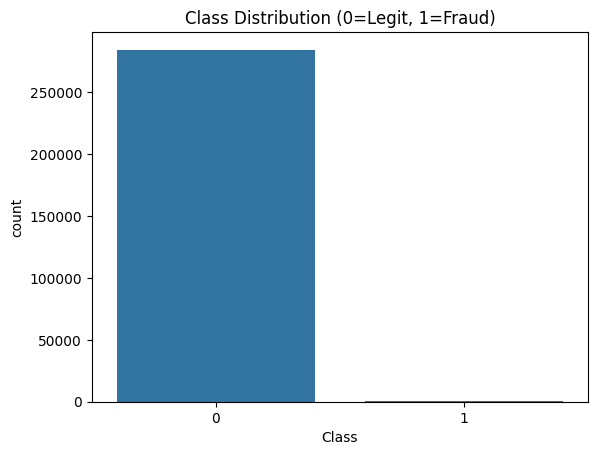

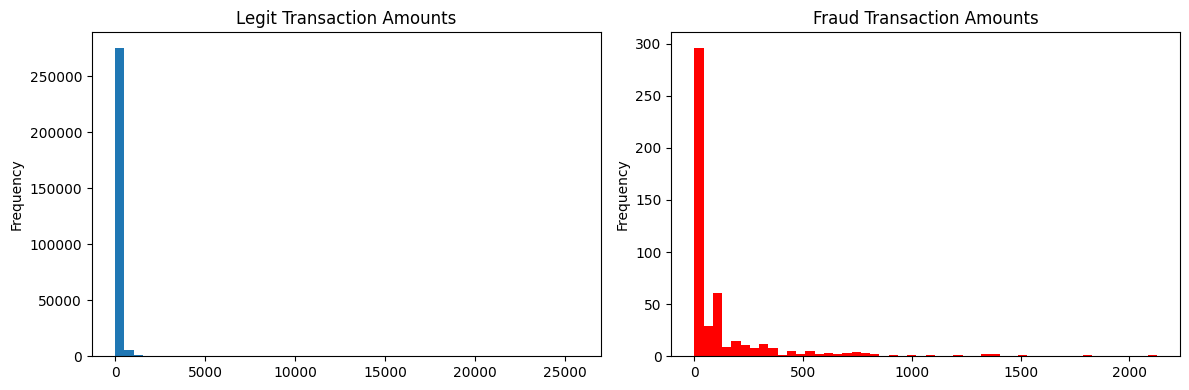

In [ ]:
# Class distribution
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Legit, 1=Fraud)")
plt.savefig("class_distribution.png")
plt.show()

# Fraud vs legit transaction amount
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
df[df["Class"]==0]["Amount"].plot(ax=ax1, title="Legit Transaction Amounts", bins=50, kind="hist")
df[df["Class"]==1]["Amount"].plot(ax=ax2, title="Fraud Transaction Amounts", bins=50, kind="hist", color="red")
plt.tight_layout()
plt.savefig("amount_distribution.png")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time (other features are already scaled)
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(["Amount", "Time"], axis=1)

# Split
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (227845, 30), Test size: (56962, 30)


In [ ]:
# Handle imbalance using class_weight
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {"ROC-AUC": round(roc, 4)}
    print(f"\n{name}")
    print(classification_report(y_test, preds))

print(pd.DataFrame(results).T)


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

                     ROC-AUC
Logistic Regression   0.9722
Random Forest         0.9581


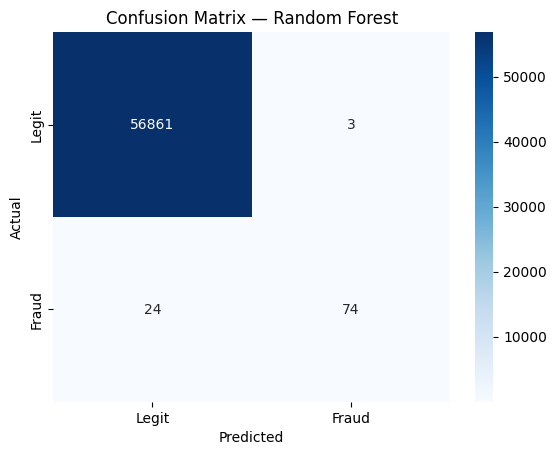

In [ ]:
best_model = models["Random Forest"]
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png")
plt.show()